# 08 — Language Requirements

German and English language requirements extracted from job descriptions. Examines which job families mandate German, what CEFR proficiency levels are requested, and how language requirements interact with remote work modality.

In [1]:
from analysis.utils import notebook_init
from analysis.filters import exclude_future_dates, exclude_other_family

df_raw = notebook_init()
df = exclude_future_dates(df_raw)
print(f"After excluding future-dated rows: {len(df):,} rows")

Loaded 18,949 rows × 25 columns
After excluding future-dated rows: 18,899 rows


In [2]:
from analysis import charts as _charts
from analysis.charts import horizontal_bar, stacked_bar, heatmap, value_bar
from shared.json_utils import parse_json_list

import pandas as pd

## Data Quality: Language Data Coverage

In [3]:
# Simple string-based checks (fast, avoids full JSON parsing per row)
has_any_lang = df["languages"].apply(lambda v: bool(parse_json_list(v))).sum()
has_german = df["languages"].apply(lambda v: "german" in str(v).lower() if pd.notna(v) else False).sum()
has_english = df["languages"].apply(lambda v: "english" in str(v).lower() if pd.notna(v) else False).sum()
has_both = df["languages"].apply(
    lambda v: "german" in str(v).lower() and "english" in str(v).lower() if pd.notna(v) else False
).sum()
has_neither = len(df) - has_any_lang

print(f"Total postings: {len(df):,}")
print(f"With any language requirement: {has_any_lang:,} ({has_any_lang/len(df)*100:.1f}%)")
print(f"Without language info:         {has_neither:,} ({has_neither/len(df)*100:.1f}%)")
print()

# Summary table
summary = pd.DataFrame([
    {"Language": "German required", "Count": has_german, "%": f"{has_german/len(df)*100:.1f}%"},
    {"Language": "English required", "Count": has_english, "%": f"{has_english/len(df)*100:.1f}%"},
    {"Language": "Both required", "Count": has_both, "%": f"{has_both/len(df)*100:.1f}%"},
    {"Language": "Neither specified", "Count": has_neither, "%": f"{has_neither/len(df)*100:.1f}%"},
]).set_index("Language")
summary

Total postings: 18,899
With any language requirement: 7,962 (42.1%)
Without language info:         10,937 (57.9%)



,Count,%
Language,,
German required,6889,36.5%
English required,5263,27.8%
Both required,4191,22.2%
Neither specified,10937,57.9%


**Takeaway:** Language requirements are present in the majority of postings. German is by far the most commonly required language, reflecting the domestic market context. The "neither specified" group likely includes postings that assume German proficiency implicitly or simply omit language fields.

## German Required % by Job Family

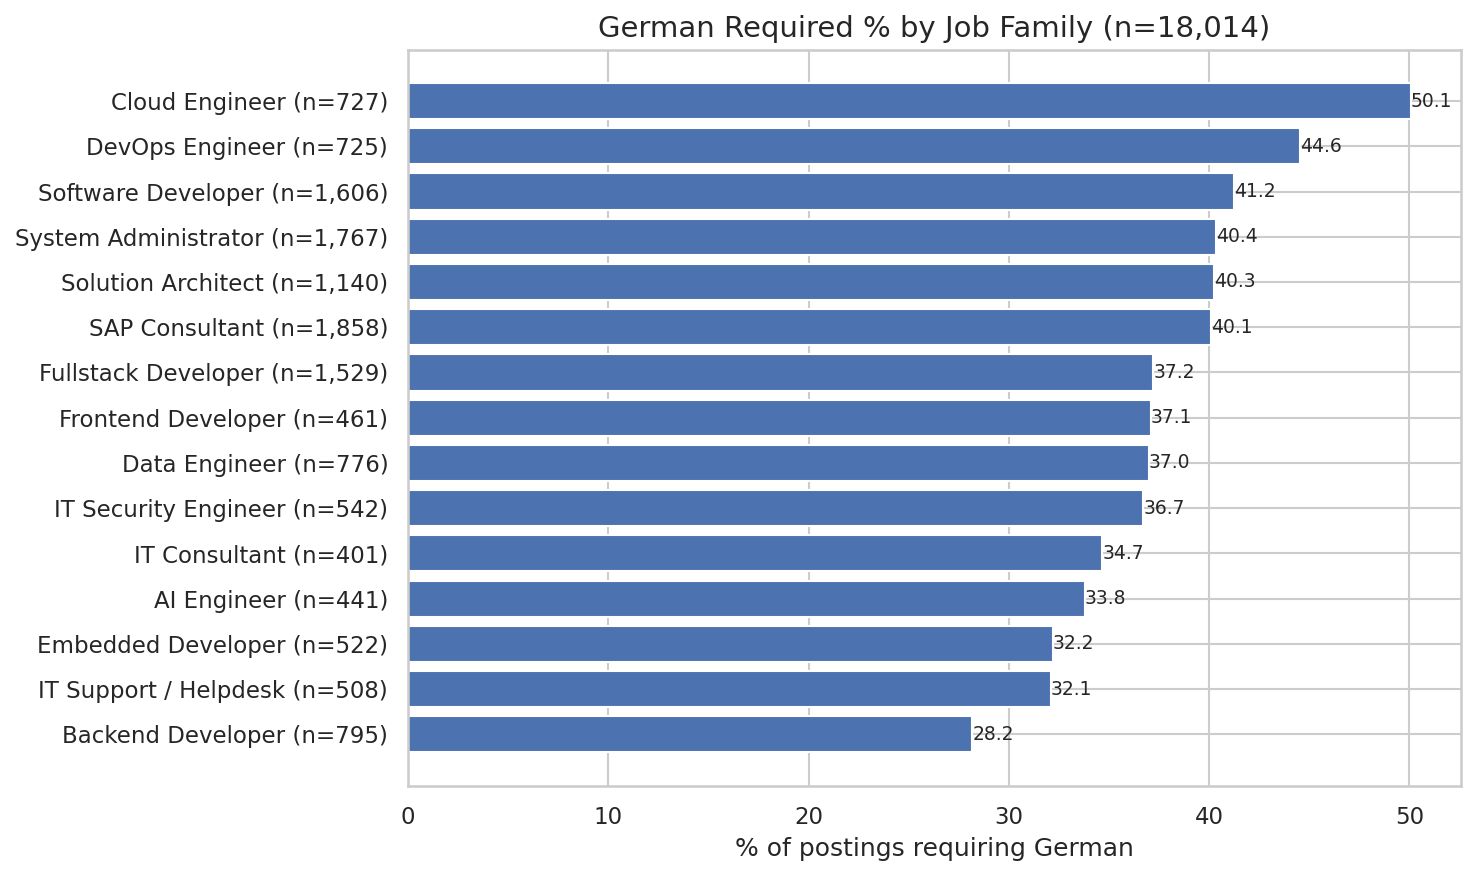

In [4]:
df2 = df.copy()
df2["has_german"] = df2["languages"].apply(lambda v: "german" in str(v).lower() if pd.notna(v) else False)
df2_fam = exclude_other_family(df2)
top_families = df2_fam["job_family"].value_counts().head(15).index

grp = df2_fam[df2_fam["job_family"].isin(top_families)].groupby("job_family")
german_pct = (grp["has_german"].mean().sort_values() * 100)
family_n = grp.size()

labels = [f"{fam} (n={family_n[fam]:,})" for fam in german_pct.index]

value_bar(
    labels,
    german_pct.values,
    f"German Required % by Job Family (n={len(df2_fam):,})",
    xlabel="% of postings requiring German",
    fmt=".1f",
    save_as="08_german_family.png",
)

**Takeaway:** German language requirements vary significantly by role. Customer-facing and management roles tend to require German more often, while highly technical roles (e.g., Data Science, Backend Development) are more likely to operate in English-only environments, reflecting the international nature of engineering teams.

## CEFR Level Distribution

Total CEFR-level mentions: 12,153 (from 7,962 postings)


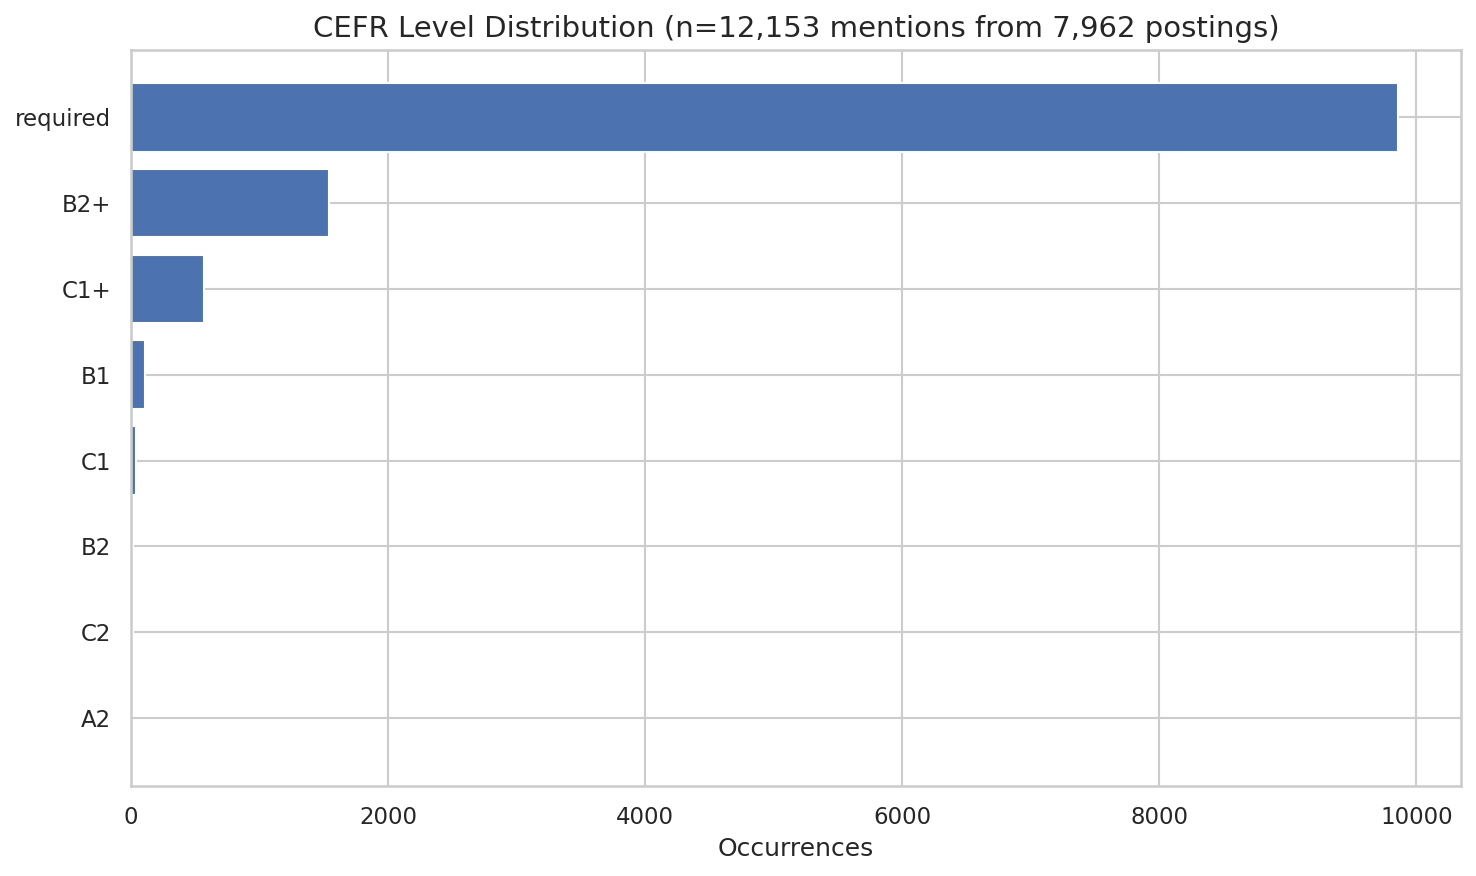

In [5]:
# Extract all CEFR levels from the JSON language data
cefr_levels = []
for val in df["languages"]:
    for lang in parse_json_list(val):
        if isinstance(lang, dict) and lang.get("level"):
            cefr_levels.append(lang["level"])

cefr_series = pd.Series(cefr_levels)
n_with_cefr = len(cefr_series)
n_postings_with_cefr = df["languages"].apply(
    lambda v: any(isinstance(lang, dict) and lang.get("level") for lang in parse_json_list(v))
).sum()

print(f"Total CEFR-level mentions: {n_with_cefr:,} (from {n_postings_with_cefr:,} postings)")

horizontal_bar(
    cefr_series,
    f"CEFR Level Distribution (n={n_with_cefr:,} mentions from {n_postings_with_cefr:,} postings)",
    xlabel="Occurrences",
    save_as="08_cefr_levels.png",
)

**Takeaway:** When CEFR levels are specified, B1–B2 (intermediate) dominates for German, while C1–C2 (advanced/fluent) is common for English. Many postings use vague terms like "good" or "fluent" rather than formal CEFR codes, so these counts represent only the subset of postings with explicit proficiency levels.

## CEFR Levels by Language (German vs English)

CEFR mentions by language (n=12,152):
language  English  German
level                    
A2              1       0
B1              2     109
B2             12       8
C1              7      30
C2              1      14
B2+           617     926
C1+            69     502
required     4554    5300



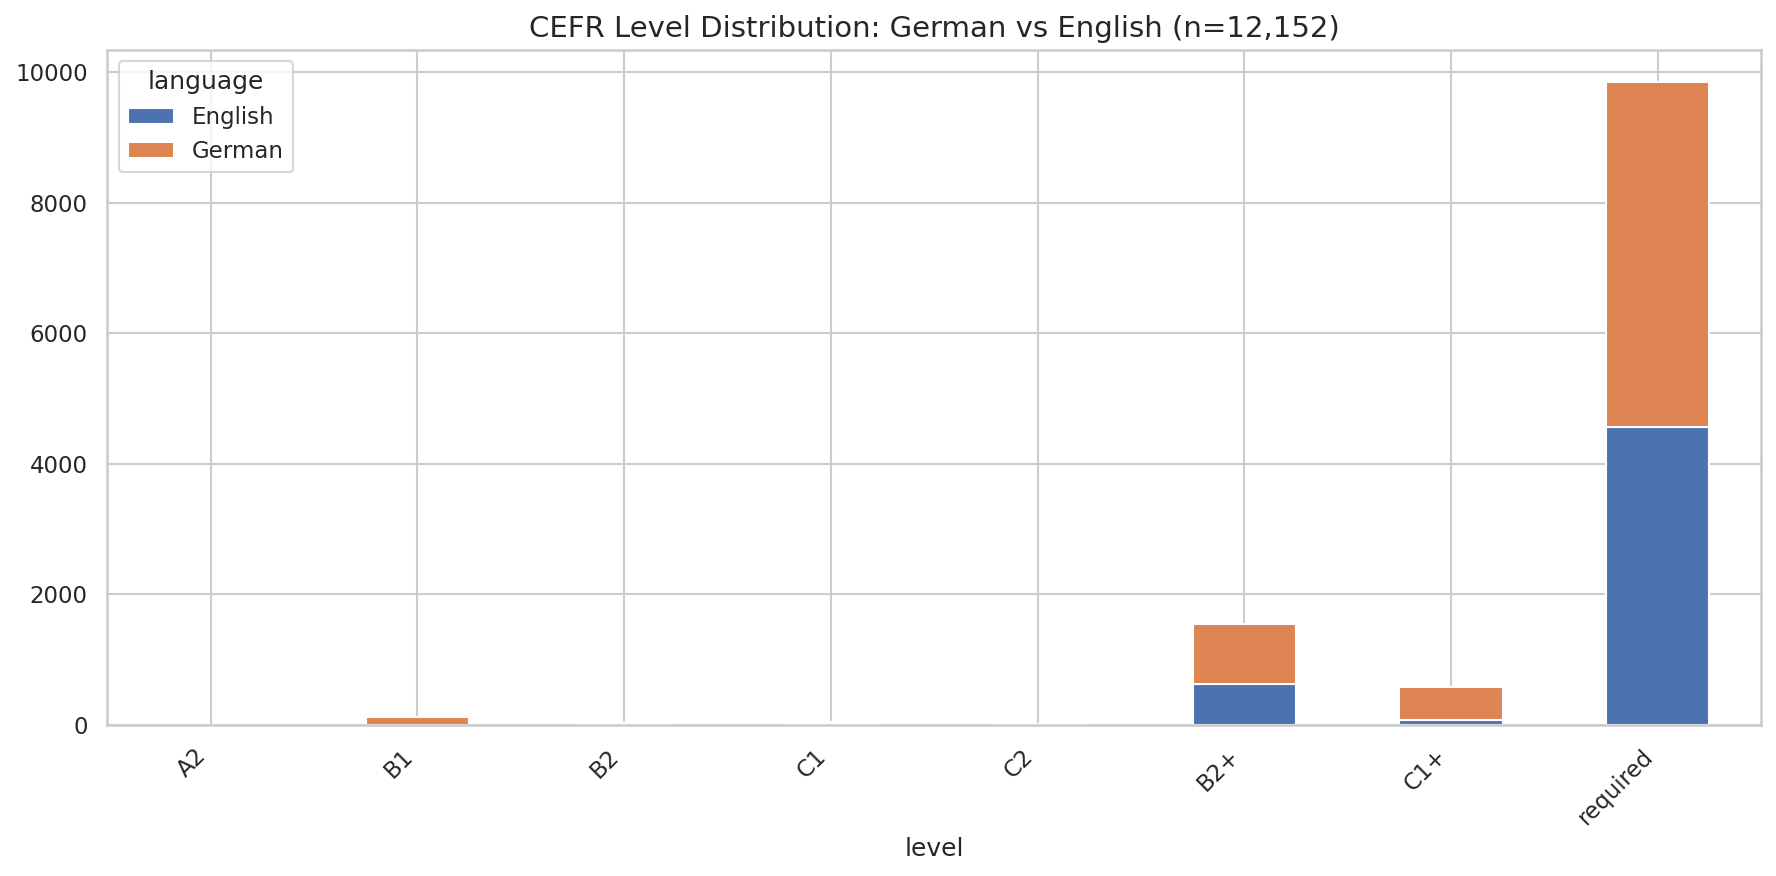

In [6]:
# Split CEFR by German vs English
cefr_by_lang = []
for val in df["languages"]:
    for lang in parse_json_list(val):
        if isinstance(lang, dict) and lang.get("level") and lang.get("language"):
            cefr_by_lang.append({
                "language": lang["language"],
                "level": lang["level"],
            })

cefr_df = pd.DataFrame(cefr_by_lang)
if len(cefr_df) > 0:
    # Focus on German and English
    cefr_df = cefr_df[cefr_df["language"].str.lower().isin(["german", "english"])]
    cefr_df["language"] = cefr_df["language"].str.title()

    ct = pd.crosstab(cefr_df["level"], cefr_df["language"])
    # Order CEFR levels logically
    cefr_order = ["A1", "A2", "B1", "B2", "C1", "C2"]
    existing = [lvl for lvl in cefr_order if lvl in ct.index]
    other = [lvl for lvl in ct.index if lvl not in cefr_order]
    ct = ct.reindex(existing + other)

    print(f"CEFR mentions by language (n={len(cefr_df):,}):")
    print(ct)
    print()

    stacked_bar(
        ct,
        f"CEFR Level Distribution: German vs English (n={len(cefr_df):,})",
        save_as="08_cefr_by_language.png",
    )
else:
    print("No CEFR data with language info available.")

**Takeaway:** The CEFR profile differs between German and English requirements. German postings more often specify intermediate levels (B1/B2), suggesting employers are open to non-native speakers with functional German. English requirements cluster at higher levels (B2/C1), reflecting the expectation of professional-level English for technical communication.

## English-Only Roles

English-only roles: 1,072 (5.7%)


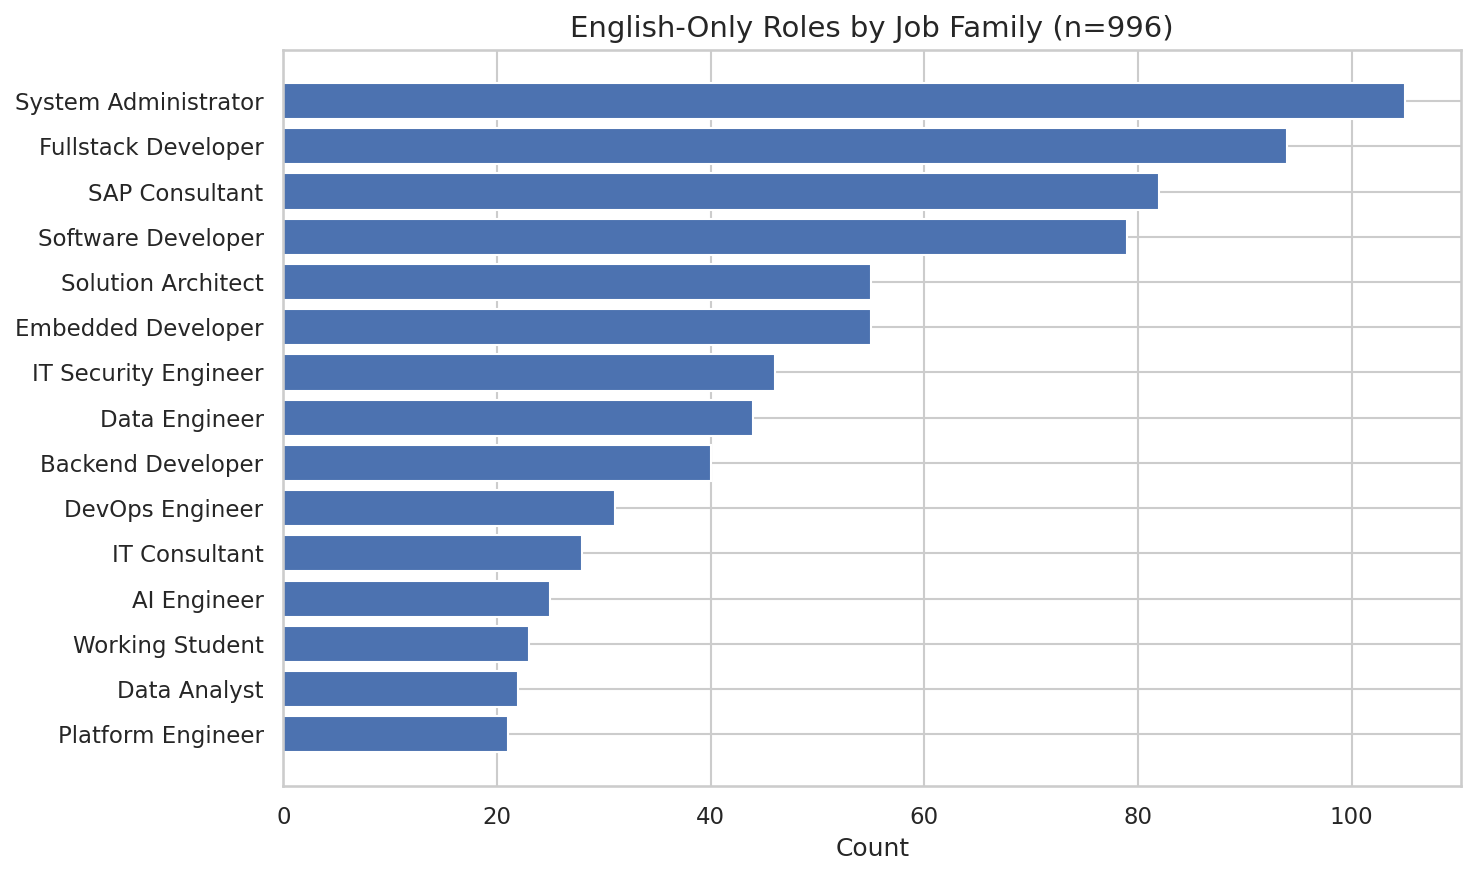

In [7]:
df3 = df.copy()
df3["has_english"] = df3["languages"].apply(lambda v: "english" in str(v).lower() if pd.notna(v) else False)
df3["has_german"] = df3["languages"].apply(lambda v: "german" in str(v).lower() if pd.notna(v) else False)

english_only = df3[df3["has_english"] & ~df3["has_german"]]
n_eng_only = len(english_only)
print(f"English-only roles: {n_eng_only:,} ({n_eng_only/len(df)*100:.1f}%)")

english_only_fam = exclude_other_family(english_only)
horizontal_bar(
    english_only_fam["job_family"],
    f"English-Only Roles by Job Family (n={len(english_only_fam):,})",
    top_n=15,
    save_as="08_english_only.png",
)

**Takeaway:** English-only roles are concentrated in highly technical job families such as Data Science, Backend Development, and DevOps/Cloud. These roles are more likely to be part of internationally distributed teams where English is the working language, making them attractive for international candidates without strong German skills.

## Language Requirement × Work Modality

Language × Modality breakdown (row-normalised):
work_modality    Hybrid  On-site  Remote
has_german                              
German required    57.2      6.2    36.6
No German          48.8      8.2    43.0



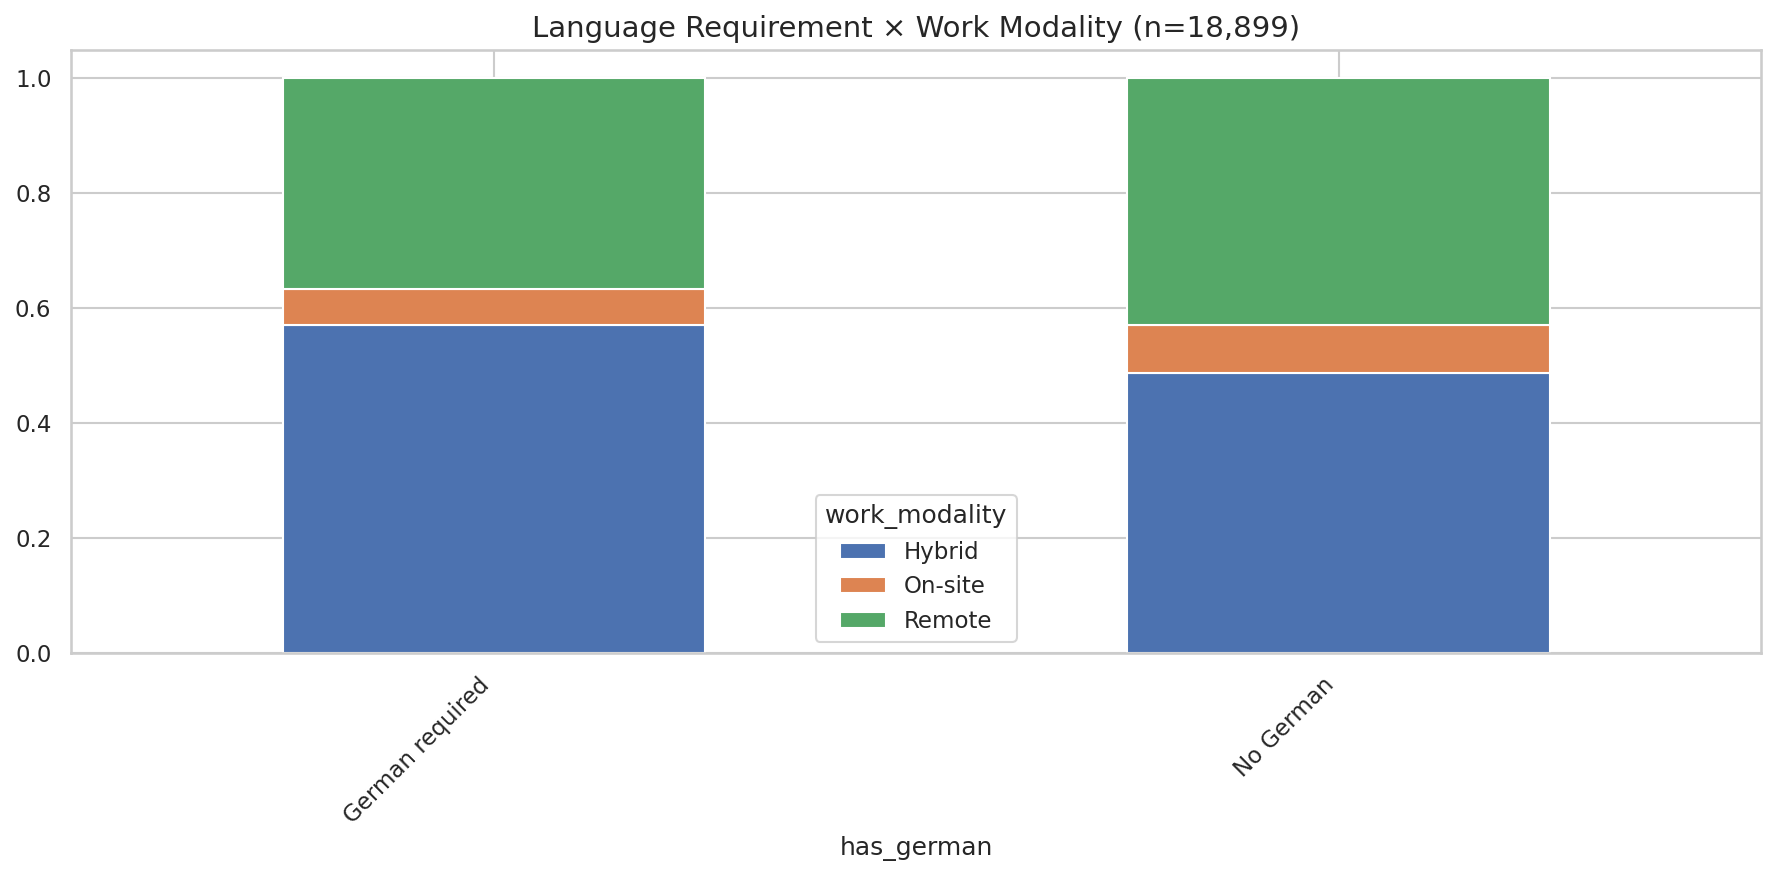

In [8]:
ct_lang_modality = pd.crosstab(
    df3["has_german"].map({True: "German required", False: "No German"}),
    df3["work_modality"],
    normalize="index",
)

print("Language × Modality breakdown (row-normalised):")
print((ct_lang_modality * 100).round(1))
print()

stacked_bar(
    ct_lang_modality,
    f"Language Requirement × Work Modality (n={len(df3):,})",
    save_as="08_lang_modality.png",
)

**Takeaway:** Roles that do not require German are more likely to offer remote work, which makes sense: if the company already operates in English, geographic flexibility is easier. For job seekers without strong German, targeting remote-friendly roles significantly expands the opportunity set.